# Watershed Project

### Project Overview

A watershed is a geographic area where all the rain and runoff drains downhill into a body of water like an ocean or a river. Watersheds are very important because they recharge local drinking water when rain seeps into underground aquifers. They protect coastal wetlands by slowing runoff and preventing erosion. Southern California has experienced increasingly frequent and severe wildfires in recent decades. The erosion that results from the loss of vegetation causes flooding and mudslides among other negative effects. 
In this project, I analyzed the fire risk posed to the 11 watersheds in Orange County, California by measuring how much of each watershed overlaps CAL FIRE's 'Very High' Fire Hazard Severity Zones. I also used CAL FIRE's historical fire perimeter dataset to validate this by measuring the percent of area burned by fires that occured in each watershed. 

### Data Loading and Cleaning

In [712]:
import folium
from folium import Marker, GeoJson
from folium import Choropleth, Circle, Marker
from folium.plugins import HeatMap

import pandas as pd
import geopandas as gpd
print(gpd.__version__)

1.1.4


In [713]:
zones_oc = gpd.read_file(r"C:\Users\nikhi\Downloads\Fire_Project\fire hazard zones oc\fhszs06_3_30.shp")
tier_2 = gpd.read_file(r"C:\Users\nikhi\Downloads\Fire_Project\Tier 2 hazard\California_High_Hazard_Zones_Tier_2.shp")
oc_boundaries = gpd.read_file(r"C:\Users\nikhi\Downloads\Fire_Project\City_Boundaries.geojson")
oc_watersheds = gpd.read_file(r"C:\Users\nikhi\Downloads\Fire_Project\Regional_Watersheds.geojson")
fires_past = gpd.read_file(r"C:\Users\nikhi\Downloads\Fire_Project\California_Historic_Fire_Perimeters_-4891938132824355098.geojson")

In [714]:
zones_oc.head()

,SRA,HAZ_CODE,HAZ_CLASS,Shape_Leng,Shape_Area,geometry
0,SRA,1,Moderate,3778.646498,2.277258e+05,"POLYGON ((223350 -496380, 223350 -496410, 2233..."
1,SRA,1,Moderate,6048.431446,5.714470e+05,"POLYGON ((220560 -497271.321, 220350 -497126.3..."
2,SRA,1,Moderate,10367.851705,1.249876e+06,"POLYGON ((225060 -495480, 225060 -495510, 2250..."
3,SRA,1,Moderate,2640.540307,1.125381e+05,"POLYGON ((222870 -494550, 222870 -494580, 2229..."
4,SRA,1,Moderate,25081.459985,3.405565e+06,"POLYGON ((219781.988 -491241.638, 219785.747 -..."


In [715]:
tier_2.head()

,OBJECTID,HYDROREGIO,ACRES,DESIGNATIO,DATE_,WATERSHEDN,WATERSHE_1,FIRENAME,INCIDENTNU,SHAPEAREA,SHAPELEN,geometry
0,6,CentralSouthCoast,74405.742867,Office,None,Little Pico Creek-Frontal Pacific Ocean,180600060407,NaN,NaN,1.588025e+08,177884.211020,"MULTIPOLYGON (((-121.32117 35.75992, -121.3207..."
1,7,CentralSouthCoast,24622.453719,Office,None,Lower San Antonio Creek,180600090105,NaN,NaN,1.480534e+08,67982.244823,"POLYGON ((-120.49391 34.82785, -120.49307 34.8..."
2,8,CentralSouthCoast,28729.252726,Office,None,Hames Creek,180600050803,NaN,NaN,1.775296e+08,81031.403549,"POLYGON ((-120.9886 35.97519, -120.98856 35.97..."
3,9,CentralSouthCoast,29324.485102,Office,None,Sam Jones Canyon-San Antonio River,180600050707,NaN,NaN,1.815058e+08,90760.073295,"POLYGON ((-121.13876 36.00098, -121.13894 36.0..."
4,10,CentralSouthCoast,61972.046936,Office,None,Meadow Creek-Frontal Pacific Ocean,180600060705,NaN,NaN,1.564918e+08,196246.448811,"MULTIPOLYGON (((-120.58966 35.16997, -120.5891..."


In [716]:
zones_oc['HAZ_CLASS'].unique()

<StringArray>
['Moderate', 'High', 'Very High']
Length: 3, dtype: str

In [717]:
tier_2['DESIGNATIO'].unique()

<StringArray>
['Office', 'Local', 'Wildfire', 'Office and Wildfire', 'Local and Wildfire']
Length: 5, dtype: str

### Fire Hazard Severity Zone Buffers

In the two cells below, I use .dissolve() to aggregate the geometries of oc_watersheds by 'Watershed' and clip it to oc_boundaries to get a cleaned data frame that only includes watersheds located in Orange County grouped by watershed name.

In [718]:
oc_watersheds = oc_watersheds.dissolve(by='Watershed').reset_index()

In [721]:
oc_watersheds = gpd.clip(oc_watersheds, oc_boundaries)

In the next three cells, I add a longitude and latitude column to zones_oc and create a folium map. I add three buffer rings at distances of 800m, 1600m, and 2400m around each 'Very High Hazard Zone'. I chose these distances because the California Fire Alliance states that 2400m (2.4km) is the average distance that firebands can travel from a wildland fire front. It is a WUI planning threshold designed to capture the majority of realistic fire risk, excluding extreme outlier events. I split them into even thirds (800/1600/2400) as a simplified linear approximation (A real ember travels non-linearly with distance). I defined a function named 'style_lambda' that sets the buffer's color depending on the buffer distance. I decided to exclude a marker for each 'Very High Hazard Zone' as it made the map cluttered.  

In [720]:
zones_oc['Longitude'] = zones_oc.representative_point().x
zones_oc['Latitude'] = zones_oc.representative_point().y

In [722]:
m = folium.Map(location=[33.75, -117.85], zoom_start=11)

In [758]:
buffer_distances = [2400, 1600, 800]
def style_lambda(j):
    return lambda feature:{"color": 'black',
                    "fillOpacity": 0.9,
                    "fillColor": "green"
                    if j == 800
                    else "#ffff00"
                    if j == 1600
                    else "#0033ff"}
for j in buffer_distances:
    buffer = zones_oc[zones_oc['HAZ_CLASS'] == 'Very High'].geometry.buffer(j)
    GeoJson(buffer, style_function=style_lambda(j)).add_to(m)
m.save('map.html')

### Choropleth Map

In the cells below, I calculate the percentage of each watershed that falls in the buffer and add it to the folium map as a choropleth gradient. I defined the buffer at the statistical threshold of 2400m (2.4km)  since gpd.buffer() includes the area up to the buffer. I do this by finding the area of the geometries where the watersheds intersect the buffer. I then group the intersection area summed up by each watershed ('OBJECTID'), and divide this by the total area of each watershed to get the percent of each watershed that falls in the buffer.

In [724]:
buffer = zones_oc[zones_oc['HAZ_CLASS'] == 'Very High'].geometry.buffer(2400)

In [725]:
multi_polygon = [buffer.geometry.union_all()]

In [726]:
buffer_gdf = gpd.GeoDataFrame(crs=3310, geometry=multi_polygon)

In [727]:
oc_watersheds = oc_watersheds.to_crs(3310)

In [728]:
watershed_to_buffer = gpd.overlay(oc_watersheds, buffer_gdf, how='intersection')

In [729]:
watershed_to_buffer['intersect_area'] = watershed_to_buffer.area

In [730]:
intersect_area_sum = watershed_to_buffer.groupby('OBJECTID')['intersect_area'].sum().reset_index()

In [731]:
oc_watersheds = oc_watersheds.merge(intersect_area_sum, how='left', on='OBJECTID').fillna(0)

In [732]:
oc_watersheds['%_watershed_in_buffer'] = oc_watersheds['intersect_area']/oc_watersheds.geometry.area * 100

In [733]:
oc_watersheds = oc_watersheds.to_crs(4326)

In [734]:
oc_watersheds['Longitude'] = oc_watersheds.representative_point().x
oc_watersheds['Latitude'] = oc_watersheds.representative_point().y

In [759]:
Choropleth(geo_data=oc_watersheds.__geo_interface__,
           data=oc_watersheds['%_watershed_in_buffer'],
           key_on='feature.id',
           fill_color='YlGnBu',
           fill_opacity=0.5,
           legend_name="Percent of Watershed in Buffer").add_to(m)
for idx, row in oc_watersheds.iterrows():
    Marker([row['Latitude'], row['Longitude']], popup= row['Watershed']).add_to(m)
m.save('map.html')

### Point Map

In the cells below, I plot points representing historical fires from CAL FIRE's historical California fire perimeter dataset. I clipped the dataset to Orange County's boundaires and plotted the fires in dark red. 

In [736]:
fires_past.is_valid.value_counts()

True     22777
False      557
Name: count, dtype: int64

In [737]:
fires_past['geometry'] = fires_past['geometry'].make_valid()

In [738]:
fires_past = fires_past.to_crs(4326)

In [739]:
oc_watersheds = oc_watersheds.to_crs(4326)

In [740]:
fires_oc = fires_past.clip(oc_watersheds)

In [741]:
fires_oc['Longitude'] = fires_oc.representative_point().x
fires_oc['Latitude'] = fires_oc.representative_point().y


In [760]:
for i in range (0, len(fires_oc)):
    Circle(location=[fires_oc.iloc[i]['Latitude'], fires_oc.iloc[i]['Longitude']],
           radius = 20,
           color = "darkred").add_to(m)
m.save('map.html')

### Historical Fires

In the cells below, I calculate the percentage of area burned by historical fires in each watershed to determine whether the watersheds with the highest amount of overlap with buffers were the most affected by historical fires. Using .dissolve(), I collapse overlapping re-burns into one geometry to avoid fires that burn in the same place multiple times. I then group by each watershed and compute the intersection area. I then merge with oc_watersheds and compute the percent for each watershed by dividing the fire intersection area by the total area of watersheds.

In [743]:
oc_watersheds = oc_watersheds.to_crs(4326)

In [744]:
fires_oc = fires_oc.to_crs(4326)

In [745]:
fires_in_watersheds = gpd.overlay(oc_watersheds, fires_oc, how="intersection")

In [746]:
dissolved = fires_in_watersheds.dissolve(by='OBJECTID_1')

In [747]:
dissolved = dissolved.to_crs(3310)

In [748]:
dissolved['intersect_area'] = dissolved.area

In [749]:
dissolved = dissolved.reset_index()

In [750]:
dissolved = dissolved[['OBJECTID_1', 'intersect_area']]

In [752]:
oc_final = oc_watersheds.merge(dissolved, how='left', left_on='OBJECTID', right_on='OBJECTID_1').fillna(0)

In [753]:
oc_final['fire_intersect_area'] = oc_final['intersect_area_y']

In [754]:
oc_final = oc_final.to_crs(3310)

In [755]:
oc_final['%_fire_in_watershed'] = oc_final['fire_intersect_area']/oc_final.geometry.area * 100

In [785]:
oc_final = oc_final.set_index('Watershed')

In [798]:
oc_final.head()

,geometry,OBJECTID,Shape__Area,Shape__Length,intersect_area_x,%_watershed_in_buffer,Longitude,Latitude,OBJECTID_1,intersect_area_y,fire_intersect_area,%_fire_in_watershed
Watershed,,,,,,,,,,,,
San Clemente,"POLYGON Z ((216142.018 -503359.146 0, 216171.9...",14,5.509607e+08,130164.866673,2.020247e+07,39.487206,-117.620069,33.444876,14.0,7.643028e+06,7.643028e+06,14.938858
San Mateo,"POLYGON Z ((224404.728 -507987.178 0, 224404.3...",16,5.265365e+08,145530.909331,4.732415e+07,96.754259,-117.543921,33.481018,16.0,3.322534e+07,3.322534e+07,67.929234
Dana Point,"POLYGON Z ((208886 -497997.382 0, 208915.718 -...",4,2.881705e+08,119089.126572,7.250732e+06,27.114313,-117.714526,33.493235,4.0,2.049493e+03,2.049493e+03,0.007664
San Juan Creek,"POLYGON Z ((228616.906 -475296.016 0, 228626.8...",15,4.391398e+09,381804.089687,3.416360e+08,83.733161,-117.575699,33.585122,15.0,2.829377e+08,2.829377e+08,69.346522
Aliso,"POLYGON Z ((208638.219 -497717.383 0, 208691 -...",1,9.689360e+08,281191.778390,5.231435e+07,58.116092,-117.700659,33.607107,1.0,1.145003e+07,1.145003e+07,12.719853


### Buffer Overlap vs Historical Fires

The bar and line graph below display a positive relationship between percentage of watershed in buffer and the percentage of historical fire in watershed. The Laguna Coast watershed is a slight outlier due to its small size; It is 100% contained in a buffer, although this doesn't necessarily mean it is the watershed most at risk. Dana Point is also another outlier due to its small size and proximity to a neighboring high-hazard watershed, which inflates its buffer percent despite it having almost no historical fire activity.

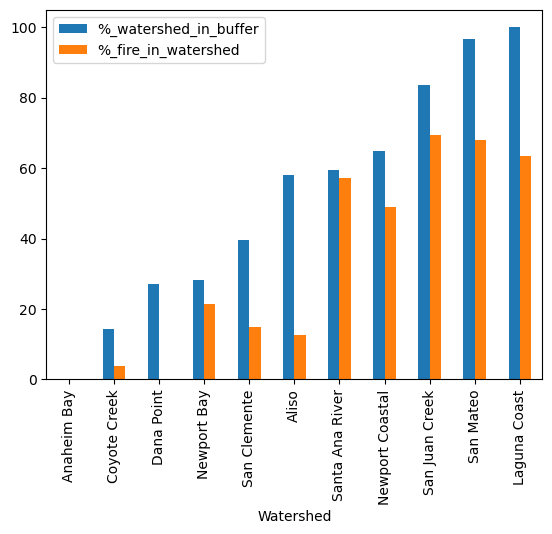

In [794]:
to_plot = pd.DataFrame({'%_watershed_in_buffer': oc_final['%_watershed_in_buffer'], '%_fire_in_watershed': oc_final['%_fire_in_watershed']}).sort_values('%_watershed_in_buffer')
ax = to_plot.plot.bar()

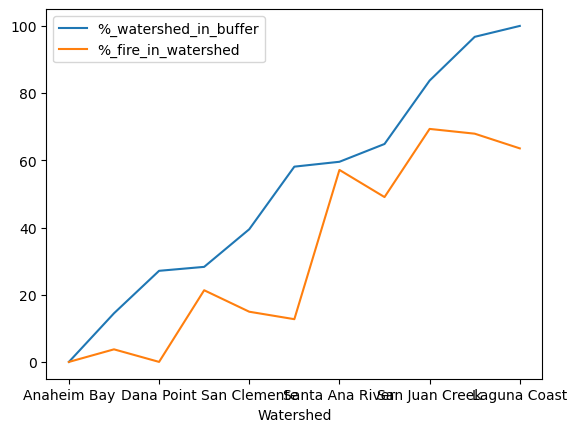

In [795]:
ax = to_plot.plot.line()

### Conclusion

My goal in this analysis was to figure out which of the 11 watersheds in Orange County, California were at the highest risk of wildfires and validate these findings with historical wildfire data. Watersheds like San Juan Creek, San Mateo, Laguna Coast and Santa Ana River overlapped the most with buffers at a distance of 2.4km from 'Very High' fire hazard severity zones. These watersheds include areas like Trabuco Canyon and Silverado Canyon, which are known for dense chaparral vegetation and fierce Santa Ana winds. Heavily urbanized watersheds like Anaheim Bay and Coyote Creek overlapped the least with the buffers and this was validated by the fact that there were very few, if any, historical wildfires. These watersheds tend to see fewer large wildfires due to the lack of continuous stretches of highly flammable chaparral brush. This analysis can help pinpoint the watersheds that are most at risk of fires and aim conservation and prevention efforts towards these areas. 